## Look at NTS data

In [1]:
import tqdm
import gaps_tof as gt
import rust_dataclasses as rd

import numpy as np
import pylab as p 
import dashi as d
import hepbasestack as hep
import hepbasestack.layout as lo
hep.visual.set_style_present()
d.visual()

%config InlineBackend.figure_format = 'retina'

In [2]:
# get tof events
events = gt.unpack_tofevents('/srv/gaps/gaps-online-software/tof/liftof/liftof-analysis/combined_0.tof.gaps')

[2023-09-01 10:58:52.860] [error] No header found!
[2023-09-01 10:58:52.860] [info] Read 10732 TofEvents!


In [3]:
calib = gt.RBCalibration.from_txtfile('/data0/gaps/nts/calibrations/1/txt-files/rb01_cal.txt')

[2023-09-01 10:58:52.895] [info] Loaded calibration for RB 1!


In [4]:
nboards = [len(k.rbevents) for k in events]

### Check the number of participating boards in this specific dataset

[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5]


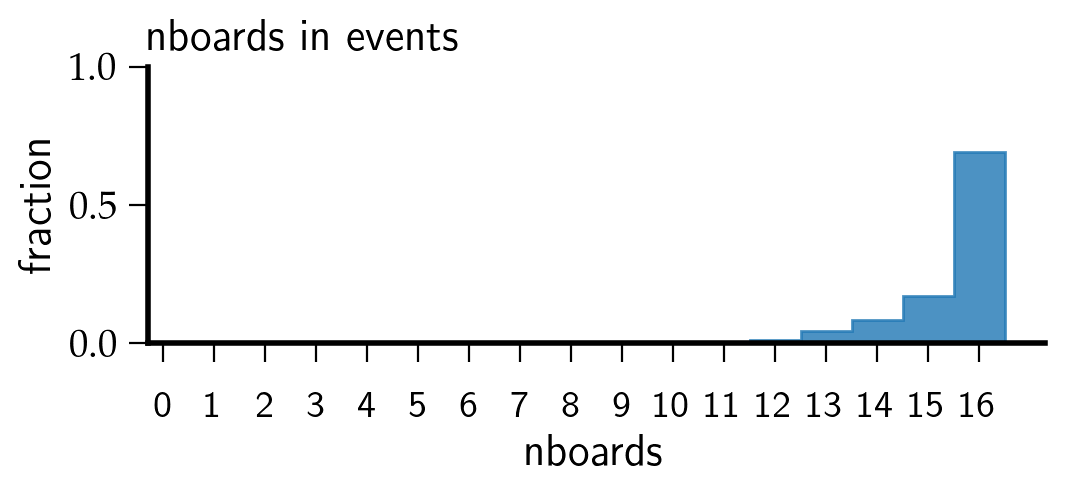

In [5]:
%matplotlib inline

bins = np.arange(0.5,17.5,1)
print (bins)

fig = p.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE_HALF_HEIGHT)
ax  = fig.gca()
xticks = [tick for tick in range(17)]
xlabels = [str(k) for k in xticks]
ax.grid(0)
ax.set_title('nboards in events', loc='left')
ax.set_ylabel('fraction')
ax.set_xlabel('nboards')
ax.set_ylim(bottom=0)
ax.set_xticks(xticks, xlabels)
h = d.factory.hist1d(nboards,bins)
h = h.normalized()
h.line(filled=True, alpha=0.8)
p.show()

In [6]:
# get some waveforms
RBID = 1
CH   = 1

rb1_ch1   = []
times     = []
voltages  = []
adcs      = []

for ev in tqdm.tqdm(events, "Reading waveforms.."):
    rbs = ev.get_rbids()
    #print (rbs)
    if RBID in rbs:
        rbev = ev.get_rbevent(RBID)
        adcs.append(np.array(rbev.get_channel_adc(CH)))
        data = (calib.nanoseconds(rbev)[CH-1], calib.voltages(rbev, spike_cleaning = True)[CH-1])
        times.append(data[0])
        voltages.append(data[1])
print(f'We got {len(voltages)} waveforms for RB{RBID} channel {CH}')

Reading waveforms..: 100%|█████████████████████████| 10732/10732 [00:00<00:00, 13637.65it/s]

We got 10519 waveforms for RB1 channel 1


In [7]:
# select only wf over 50mV
signal_wf = []
signal_t  = []
for k in range(len(voltages)):
    if max(voltages[k][:800]) > 70:
        signal_wf.append(voltages[k])
        signal_t.append(times[k])

##### importlib.reload(gt)
wf = gt.Waveform(1024)
wf.SetTime(signal_t[0])
wf.SetWave(signal_wf[0])
wf.SetPedBegin(10)
wf.SetPedRange(50)
wf.CalcPedestalRange()
wf.SubtractPedestal()
wf.SetThreshold(10)
wf.SetCFDSFraction(0.2)
wf.FindPeaks(100,300)
wf.GetNumPeaks()

for k in range(wf.GetNumPeaks()):
    wf.FindTdc(k,1)
    print (wf.GetWidth(k))
    print (wf.GetTdcs(k))

In [ ]:

waveforms = [w for w in zip(times, voltages)]      
common_time_points = np.linspace(min(curve[0].min() for curve in waveforms),
                                 max(curve[0].max() for curve in waveforms),
                                 1024)

#common_time_points = np.unique(np.concatenate(times))
interpolated_voltages = []
for w in waveforms:
    interpolated_voltages.append(np.interp(common_time_points, w[0], w[1]))

average_adc     = sum(adcs)/len(adcs)

average_voltage = np.mean(interpolated_voltages, axis=0)

In [22]:
print (len(average_voltage))
print (len(common_time_points))

1024
1024


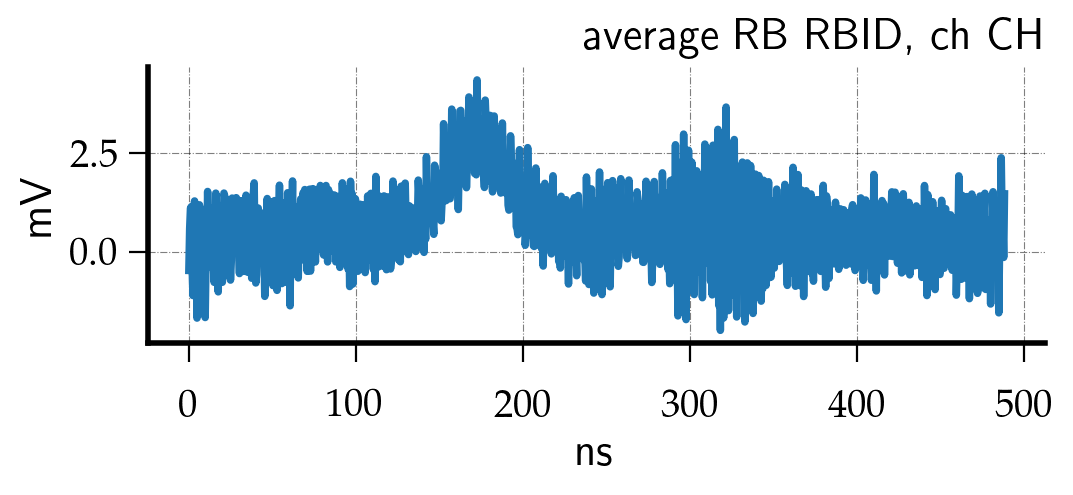

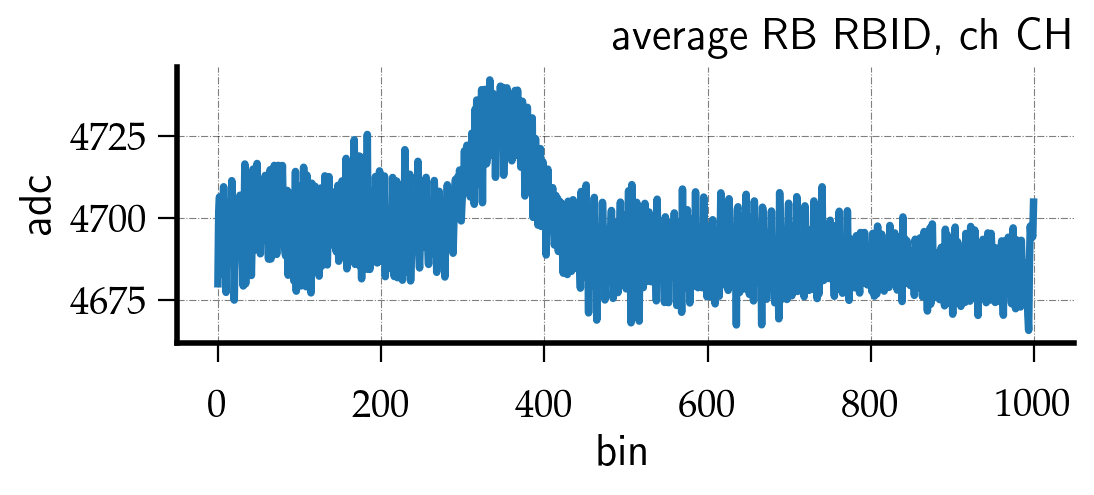

In [9]:
%matplotlib inline

# single wf example
fig1 = p.figure(figsize = lo.FIGSIZE_A4_LANDSCAPE_HALF_HEIGHT)
ax1  = fig1.gca()
ax1.set_ylabel('mV')
ax1.set_xlabel('ns')
ax1.set_title('average  RB {RBID}, ch {CH}', loc='right')
ax1.plot(common_time_points[:1000], average_voltage[:1000])
#p.show()

fig2  = p.figure(figsize = lo.FIGSIZE_A4_LANDSCAPE_HALF_HEIGHT)
ax2   = fig2.gca()
ax2.set_ylabel('adc')
ax2.set_xlabel('bin')
ax2.set_title('average  RB {RBID}, ch {CH}', loc='right')
ax2.plot(average_adc[:1000])

p.show()   

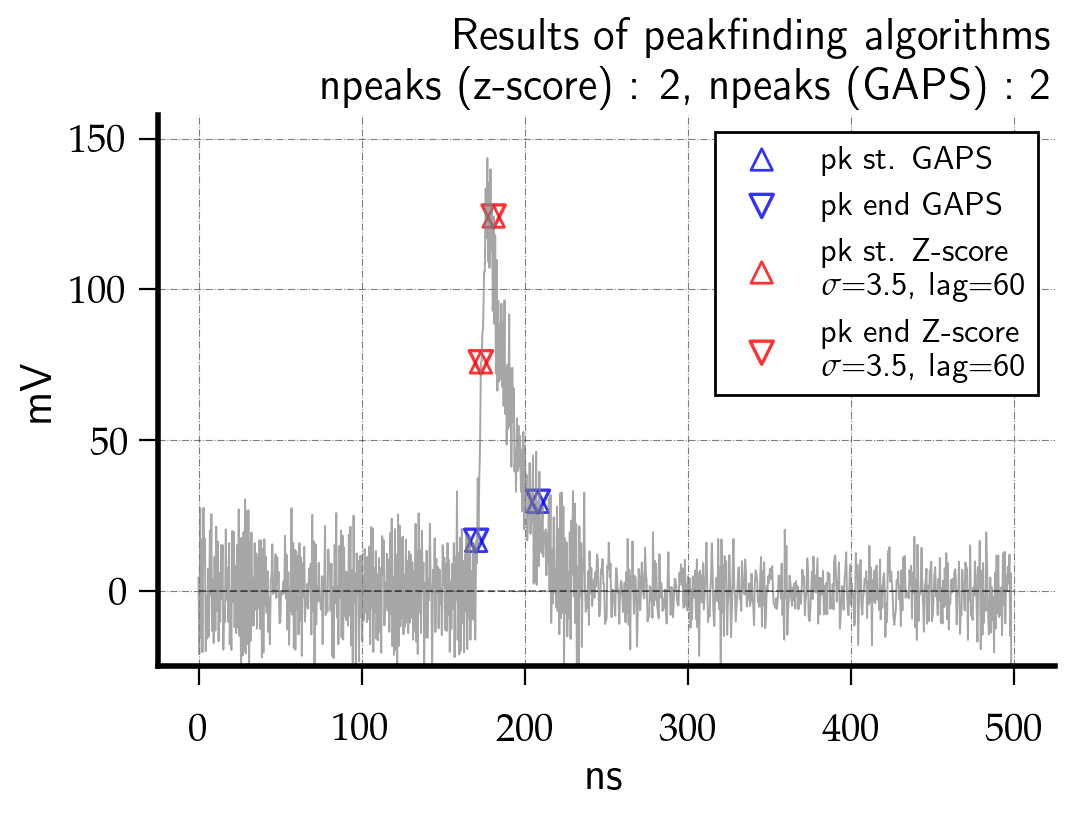

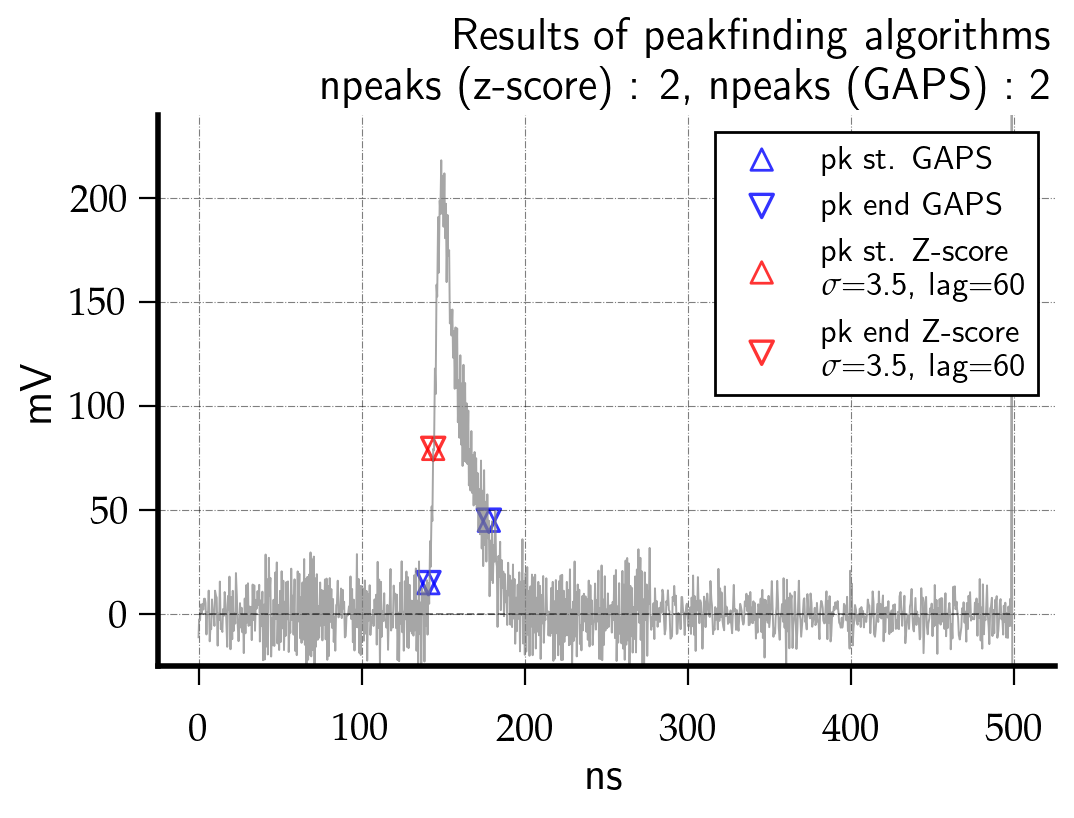

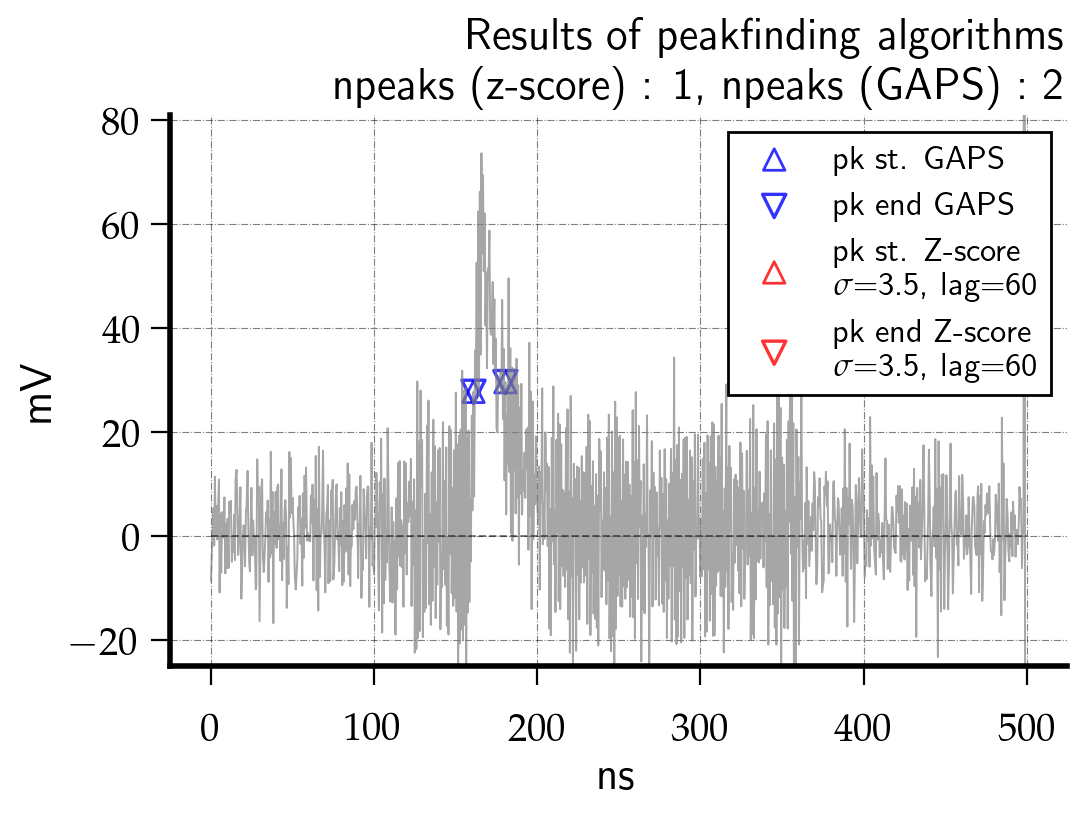

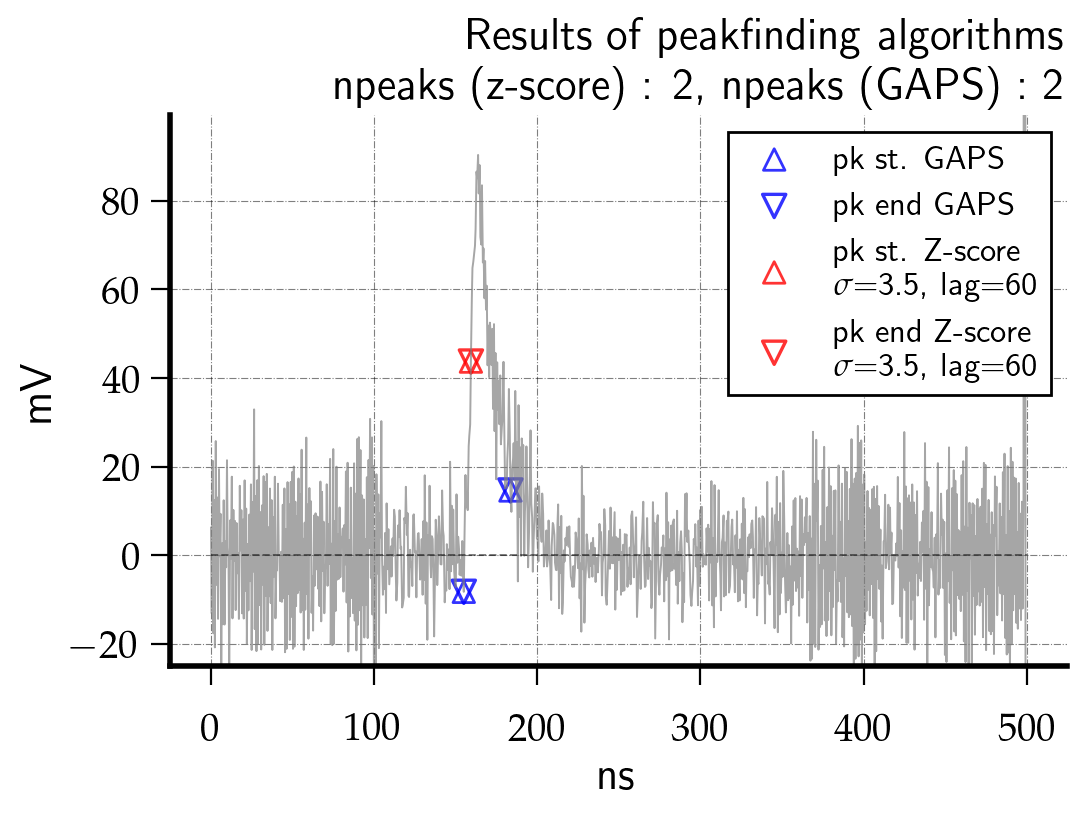

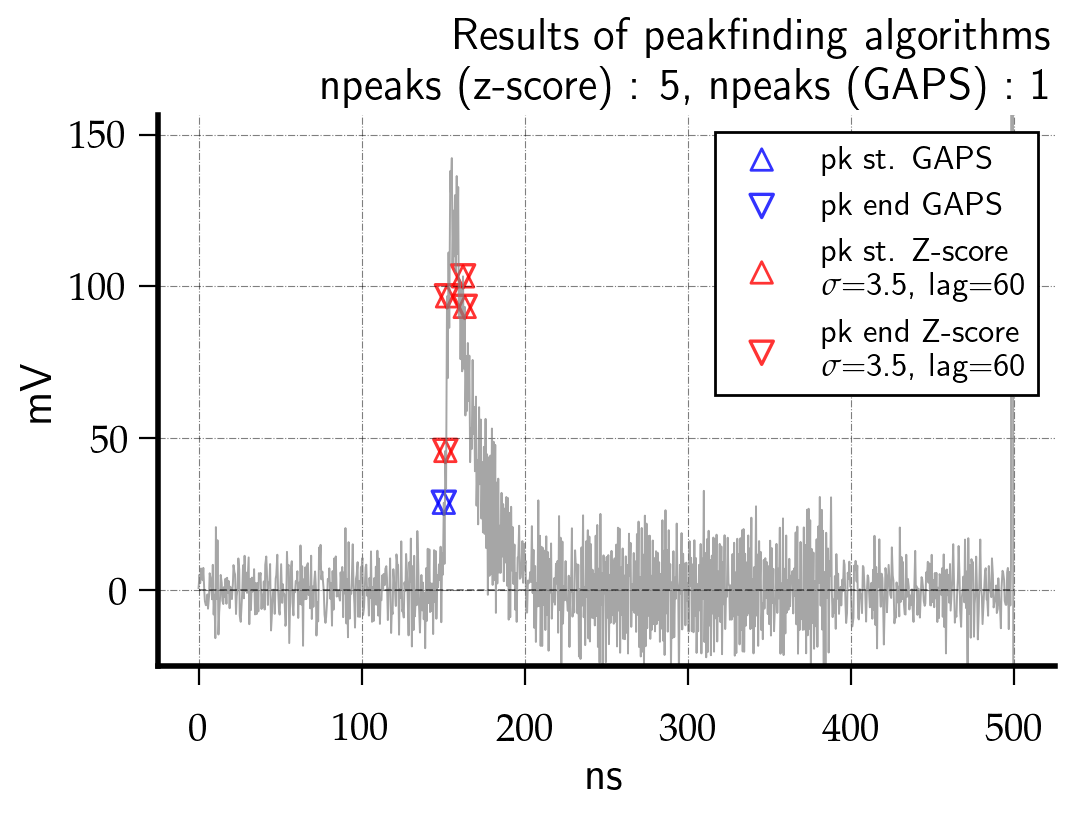

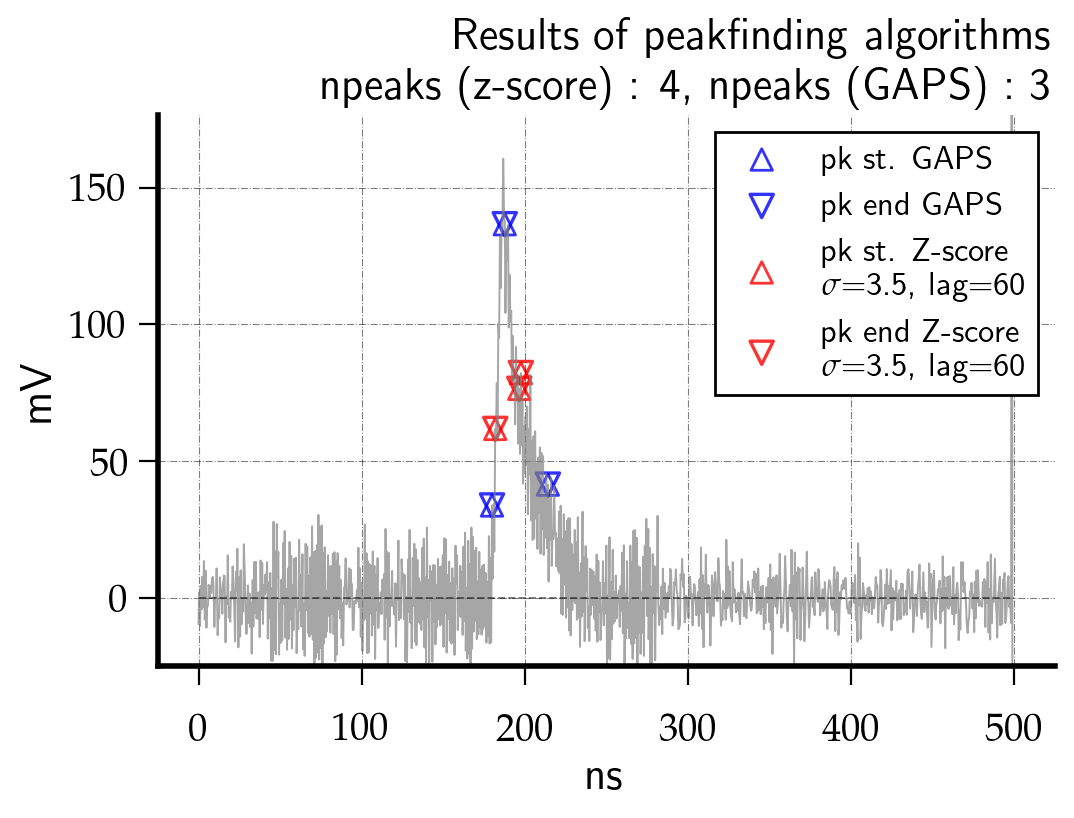

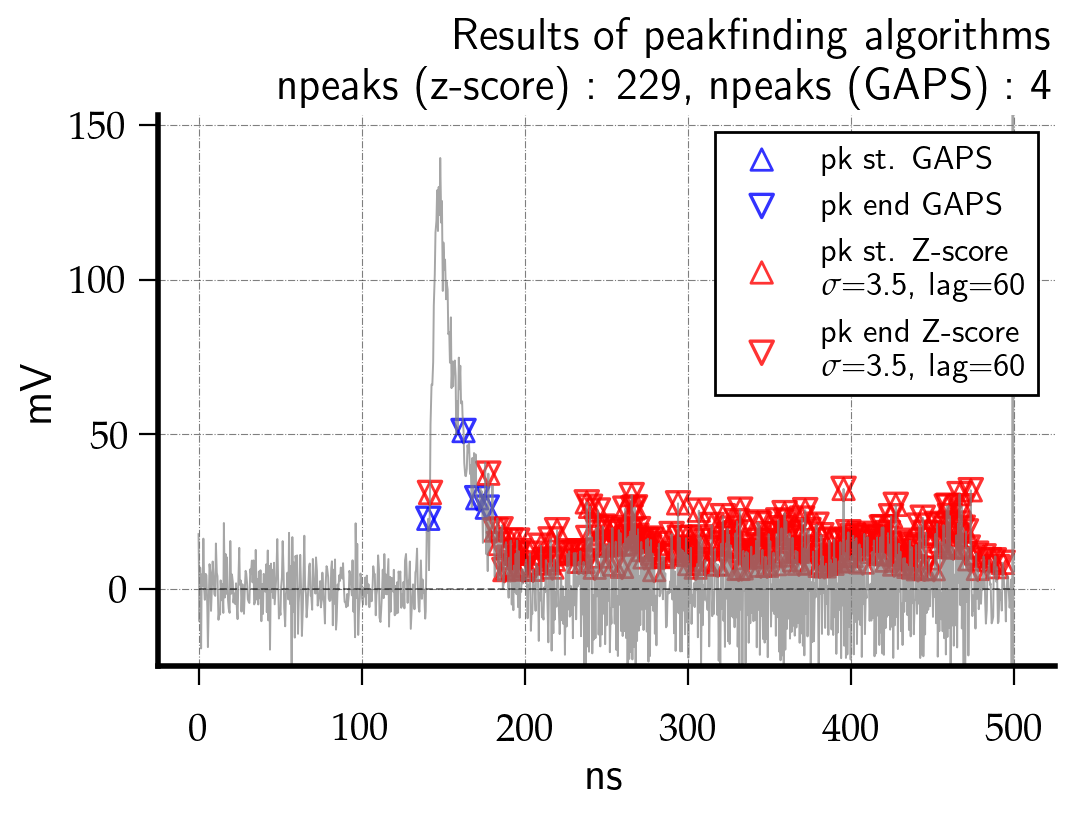

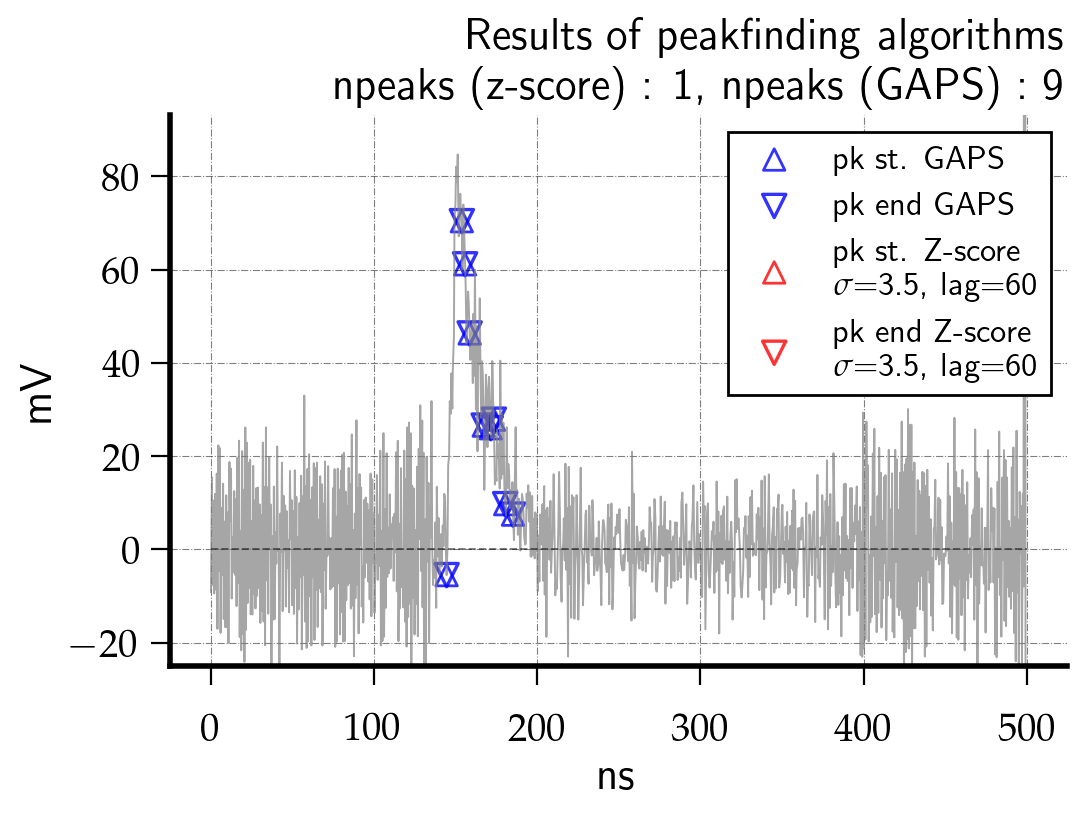

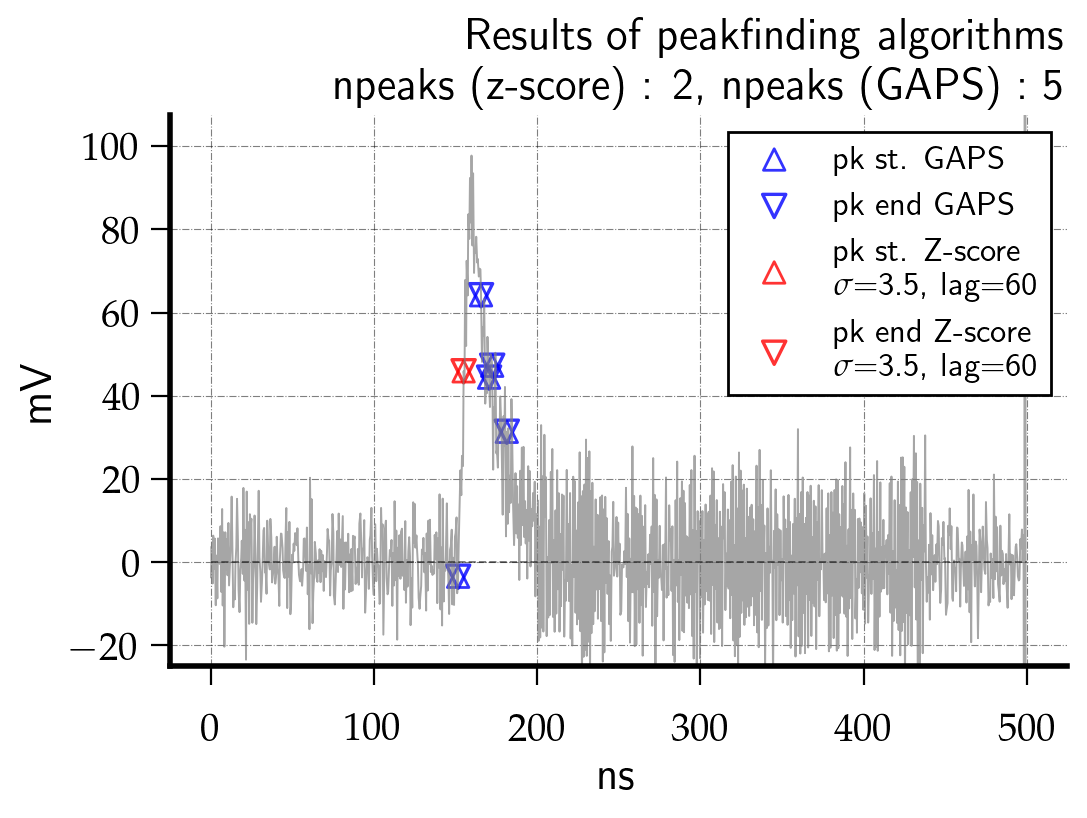

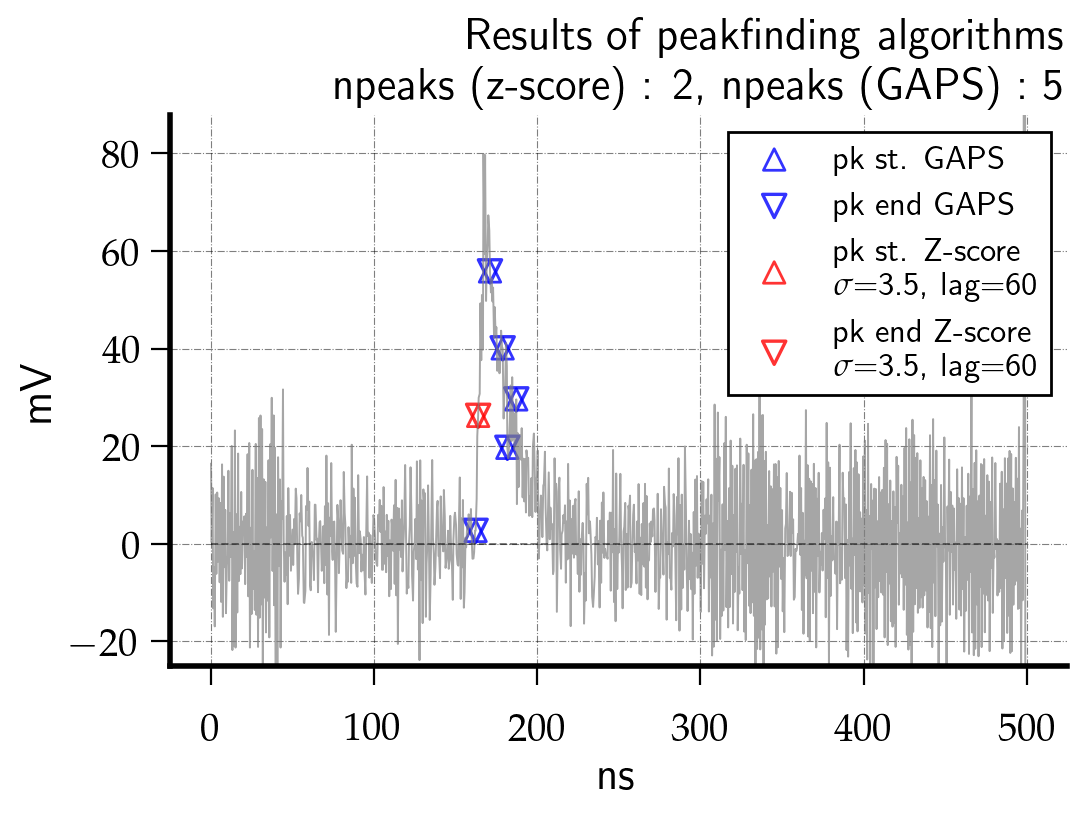

In [40]:
%matplotlib inline
import importlib
importlib.reload(rd)
def plot_wf_with_peak(event_no):
    MAX_BIN  = 1024
    EVENT_NO = event_no
    SIGMA=3.5
    LAG  =60

    fig = p.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
    ax  = fig.gca()

    ax.plot(signal_t[EVENT_NO][:MAX_BIN],signal_wf[EVENT_NO][:MAX_BIN],\
            alpha=0.7, lw=0.7, color='gray')
    peaks_gaps = rd.find_peaks(signal_wf[EVENT_NO],
                               signal_t[EVENT_NO],
                               100,300,3,10,100)
    peaks_z    = rd.find_peaks_zscore(signal_wf[EVENT_NO],
                                      signal_t[EVENT_NO],
                                      100,300,LAG,SIGMA,0.0)

    extra_label = f'$\sigma$={SIGMA}, lag={LAG}'
    npeaks_gaps   = len(peaks_gaps)
    npeaks_zscore = len(peaks_z)
    for color,label,peaks in ('b','GAPS', peaks_gaps),\
                             ('r', f'Z-score',peaks_z):

        xs_start = [signal_t[EVENT_NO][k[0]] for k in peaks]
        ys_start = [signal_wf[EVENT_NO][k[0]] for k in peaks]
        if label == 'GAPS':
            this_label = f'pk st. {label}'
        else:
            this_label = f'pk st. {label}\n{extra_label}'
        ax.scatter(xs_start,ys_start,
                   marker="^",s=60,color=color,
                   facecolor='none',alpha=0.8, label=this_label)
        xs_end = [signal_t[EVENT_NO][k[0]] for k in peaks]
        ys_end = [signal_wf[EVENT_NO][k[0]] for k in peaks]
        if label == 'GAPS':
            this_label = f'pk end {label}'
        else:
            this_label = f'pk end {label}\n{extra_label}'
        ax.scatter(xs_end,ys_end,
                   marker="v",s=70,color=color, linewidth=1.2,
                   alpha=0.8, facecolor='none', label=this_label)
        for k,start in enumerate(xs_start):
            #print (start, xs_end[k], ys_start[k])
            ax.hlines(ys_start[k],start, xs_end[k])

    ax.hlines(0, 0, 500, linestyle='dashed', color='k', alpha=0.5, lw=0.7)
    ax.set_xlabel('ns')
    ax.set_ylabel('mV')
    ax.set_title(f'Results of peakfinding algorithms\n npeaks (z-score) : {npeaks_zscore}, npeaks (GAPS) : {npeaks_gaps}',loc='right')
    ax.legend(fancybox=False, framealpha=1.0, edgecolor='k', facecolor='w', loc='upper right')
    ax.set_ylim(top=max(signal_wf[event_no][:800]) + max(signal_wf[event_no][:800])*0.1, bottom=-25)
    #print (peaks)
    fig.savefig(f'event{event_no}.png')
for k in range(10):
    plot_wf_with_peak(k)

p.show()

## Investigate spike cleaning

Plotting 9 waveforms!
Plotting 8 waveforms!


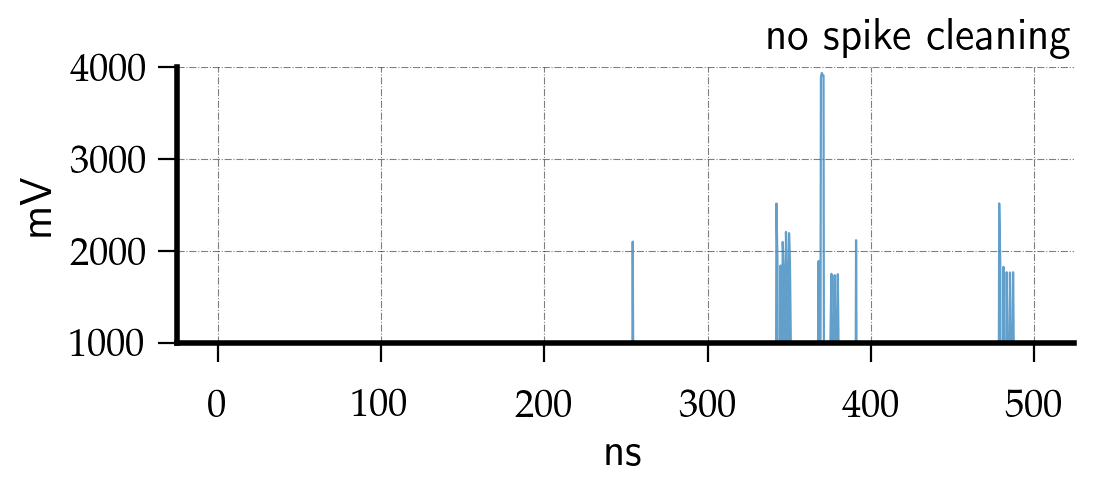

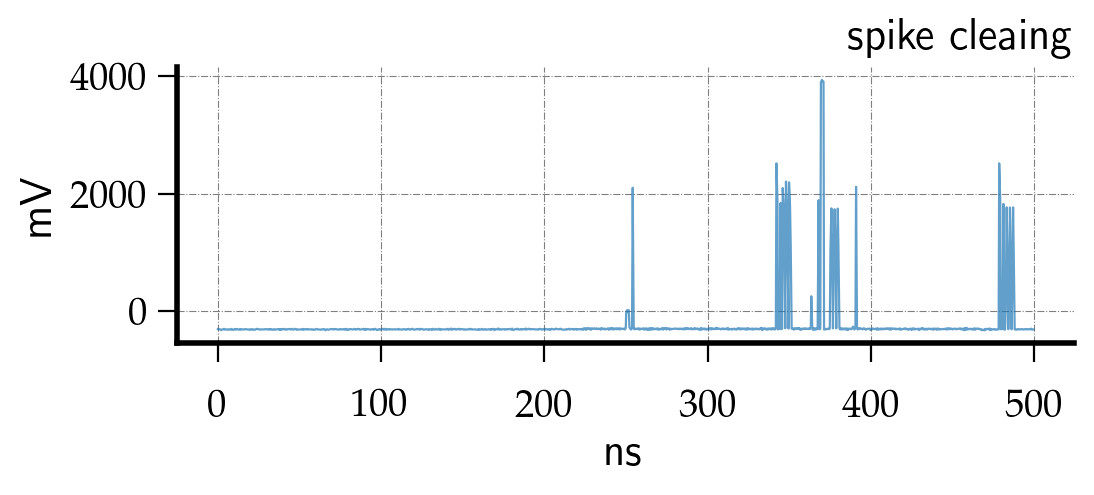

In [10]:
EVENT_INDEX = 15
ev = events[EVENT_INDEX]
rbev = ev.get_rbevent(1)
voltages = calib.voltages(rbev, spike_cleaning = False)
times    = calib.nanoseconds(rbev)

fig = p.figure(figsize = lo.FIGSIZE_A4_LANDSCAPE_HALF_HEIGHT)
ax  = fig.gca()
ax.set_ylabel('mV')
ax.set_xlabel('ns')
ax.set_ylim(top=4000)
ax.set_ylim(bottom=1000)
ax.set_title(f'no spike cleaning', loc='right')
#hep.visual.adjust_minor_ticks(ax,which='both')
print(f'Plotting {len(voltages)} waveforms!')
for k in range(8,len(voltages)):
    if max(voltages[k][:1000]) > 50:
        ax.plot(times[k], voltages[k], lw=0.8, alpha=0.7)

        voltages = calib.voltages(rbev, spike_cleaning = True)
times    = calib.nanoseconds(rbev)

fig = p.figure(figsize = lo.FIGSIZE_A4_LANDSCAPE_HALF_HEIGHT)
ax  = fig.gca()
ax.set_ylabel('mV')
ax.set_xlabel('ns')
#ax.set_ylim(top=100)
#ax.set_ylim(bottom=-50)
ax.set_title(f'spike cleaing', loc='right')
#hep.visual.adjust_minor_ticks(ax,which='both')
print(f'Plotting {len(voltages) - 1} waveforms!')
for k in range(8,len(voltages)):
    if max(voltages[k][:1000]) > 50:
        ax.plot(times[k], voltages[k], lw=0.8, alpha=0.7)


In [11]:
# channel 9

RBID = 1

robin = gt.get_rbeventmemoryviews('/data0/gaps/nts/raw/10/RB1_1686625494.blob')


[2023-09-01 03:58:44.641] [info] Read 652548784 bytes from /data0/gaps/nts/raw/10/RB1_1686625494.blob
[2023-09-01 03:58:44.641] [info] There might be at max 35215 events in the stream
[2023-09-01 03:58:45.023] [info] Retrieved 17606 events from stream!
[2023-09-01 03:58:45.023] [info] 0 times a header with no corresponding footer was found. This does not necessarily mean there is a problem, instead it could also be padding bytes introduced due to wrapper packages.


[2023-08-18 12:03:40.963] [info] Loaded calibration for RB 1!


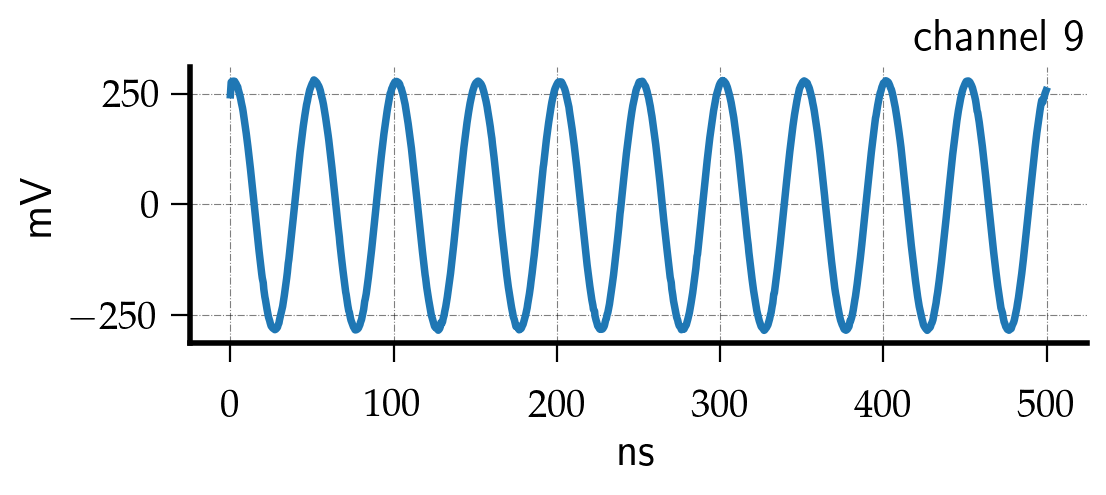

In [71]:
EVENT_INDEX = 6
rbev = robin[EVENT_INDEX]
adc  = rbev.get_channel_adc(9)
#print (adc)
bins = [k for k in range(1024)] 
calib = gt.RBCalibration.from_txtfile(f'/data0/gaps/nts/calibrations/1/txt-files/rb0{RBID}_cal.txt')
voltages = calib.voltages(rbev, spike_cleaning = False)[-1]
times    = calib.nanoseconds(rbev)[-1]

fig = p.figure(figsize = lo.FIGSIZE_A4_LANDSCAPE_HALF_HEIGHT)
ax  = fig.gca()
ax.set_ylabel('mV')
ax.set_xlabel('ns')
#ax.set_ylim(top=100)
#ax.set_ylim(bottom=-50)
ax.set_title(f'channel 9', loc='right')
#hep.visual.adjust_minor_ticks(ax,which='both')
ax.plot(times, voltages)#, alpha=0.7)